<a href="https://colab.research.google.com/github/aminta-bt/Gen-AI-Challenge/blob/main/Challenge_1_Aminta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Challenge 1: Image Repair + Style Transformation**

I started with small images of clothing using Fashion-MNIST dataset. I intentionally ruined them by adding noise. Then, I built and trained an Autoencoder to clean up the static and rebuild the original image. Finally, I used another AI to paint the repaired image in the style of Van Gogh's Starry Night.

***Tools & Models Used:*** Python, TensorFlow, Keras, and a pre-trained model from TensorFlow Hub.

***Degradation Method Used:*** Gaussian Noise (Noise Factor = 0.2 applied via numpy).

I used Fashion-MNIST because it's fast. I kept the AI model small so it would train quickly. Adding the Van Gogh style at the end proves how AI can completely change the artistic vibe of an image while perfectly keeping the original shape of the clothing.

### **Dataset Selection**

TensorFlow Version: 2.19.0
Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


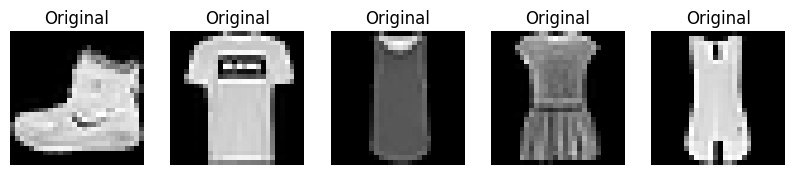

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

print(f"TensorFlow Version: {tf.__version__}")

# loading the datasets
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# normalize images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# reshape data
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")

n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)

    plt.imshow(tf.squeeze(x_train[i]), cmap='gray')
    plt.title("Original")
    plt.axis('off')
plt.show()

### **Degradation Method**

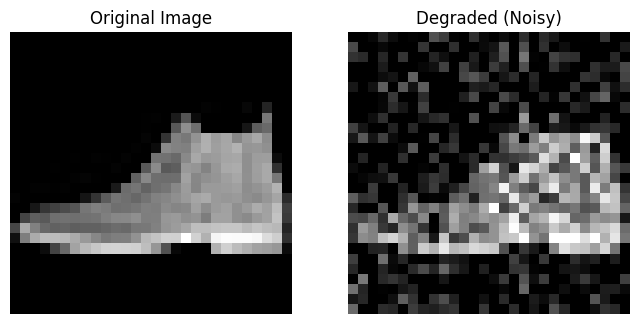

In [ ]:
# applying noise
noise_factor = 0.2
x_train_noisy = np.clip(x_train + noise_factor * np.random.normal(size=x_train.shape), 0., 1.)
x_test_noisy = np.clip(x_test + noise_factor * np.random.normal(size=x_test.shape), 0., 1.)

# original v/s noisy
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(tf.squeeze(x_test[0]), cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(tf.squeeze(x_test_noisy[0]), cmap='gray')
plt.title("Degraded (Noisy)")
plt.axis('off')
plt.show()

### **Generative Autoencoder**

Training Autoencoder... (Takes ~1 minute on GPU)
Epoch 1/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 79s 318ms/step - loss: 0.0350 - val_loss: 0.0137
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 64s 271ms/step - loss: 0.0120 - val_loss: 0.0110
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 84s 282ms/step - loss: 0.0103 - val_loss: 0.0098
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


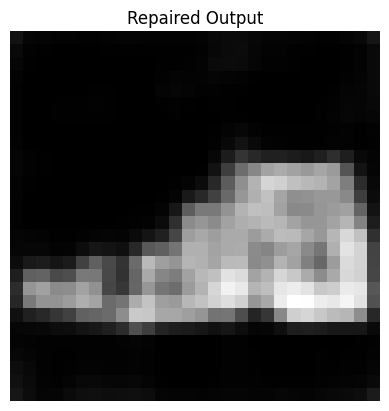

In [ ]:
# Autoencoder for 28x28 grayscale images
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

autoencoder = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), padding='same'),

    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
])

autoencoder.compile(optimizer='adam', loss='mse')

# Training (noisy as input & clean as output)
print("Training Autoencoder... (Takes ~1 minute on GPU)")
autoencoder.fit(x_train_noisy, x_train, epochs=3, batch_size=256, validation_data=(x_test_noisy, x_test))

# Predict/Repair the first test image
repaired_image = autoencoder.predict(x_test_noisy[0:1])

plt.imshow(tf.squeeze(repaired_image[0]), cmap='gray')
plt.title("Repaired Output")
plt.axis('off')
plt.show()

### **Style Transfer**

Loading Style Model...


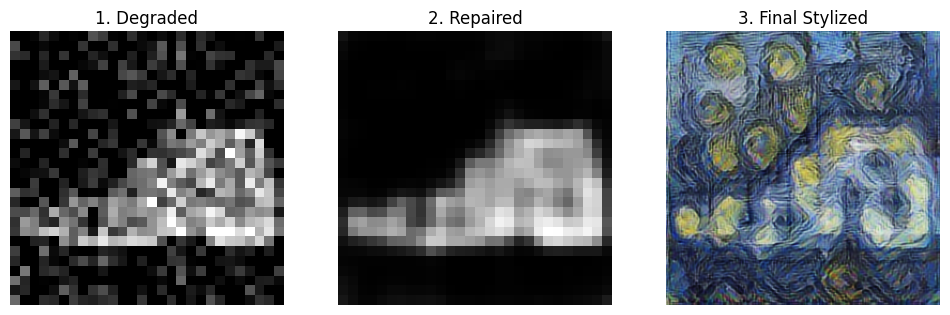

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import requests
import matplotlib.pyplot as plt
import numpy as np

# loading pre-trained style transfer model from TF Hub
print("Loading Style Model...")
hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')

# downloading Van Gogh's Starry Night
style_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/500px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg"

# Using requests with a browser header to bypass the 403 block
response = requests.get(style_url, headers={'User-Agent': 'Mozilla/5.0'})
with open("style.jpg", 'wb') as f:
    f.write(response.content)

style_img = tf.image.convert_image_dtype(plt.imread("style.jpg"), tf.float32)
style_img = tf.image.resize(style_img[tf.newaxis, ...], (256, 256))

# Resize Repaired Image and Convert Grayscale to RGB for the style model
content_img = tf.image.resize(repaired_image, (256, 256))
content_img_rgb = tf.image.grayscale_to_rgb(tf.constant(content_img))

# applying style transfer
stylized_image = hub_model(content_img_rgb, tf.constant(style_img))[0]

# o/p
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(tf.squeeze(x_test_noisy[0]), cmap='gray')
plt.title("1. Degraded")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(tf.squeeze(repaired_image[0]), cmap='gray')
plt.title("2. Repaired")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(tf.squeeze(stylized_image))
plt.title("3. Final Stylized")
plt.axis('off')
plt.show()